# 01 - Exploratory Data Analysis

Project: Finnish NHL Players: A Zone-Level Shooting Efficiency Analysis

## Purpose 
Explore the combined shot dataset to understand its structure and key distributions
before moving to formal analysis. This notebook identifies patterns, checks assumptions,
and guides the analytical decisions made in subsequent notebooks.
  
## Input
- data/processed/shots_combined.csv

## Questions explored
1. How are shots distributed across nationalities?
2. How are shots distributed across ice zones?
3. How do Finnish players compare to the NHL population in basic shooting metrics?
4. Are there any unexpected patterns or data quality issues?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROCESSED_DATA = Path('../data/processed')
dataframe = pd.read_csv(PROCESSED_DATA / 'shots_combined.csv')

print(f"Dataset loaded: {len(dataframe)} rows, {dataframe.shape[1]} columns")

Dataset loaded: 338141 rows, 126 columns


# 02 - Dataset Overview

In [2]:
print("Seasons:")
print(dataframe['season'].value_counts().sort_index())

print("Key columns:")
key_columns = ['shooterName', 'nationality', 'xGoal', 'goal', 'arenaAdjustedXCord', 'arenaAdjustedYCord', 'shotType', 'season']
print(dataframe[key_columns].head(10))

Seasons:
season
2022    113138
2023    113785
2024    111218
Name: count, dtype: int64
Key columns:
           shooterName nationality     xGoal  goal  arenaAdjustedXCord  \
0           Timo Meier         CHE  0.026009     0                47.0   
1  Marc-Edouard Vlasic         CAN  0.007774     0                45.0   
2       Mattias Ekholm         SWE  0.046070     0               -31.0   
3      Kiefer Sherwood         USA  0.296800     1               -76.0   
4       Colton Sissons         CAN  0.057435     0               -82.0   
5         Yakov Trenin         RUS  0.060461     0               -71.0   
6       Steven Lorentz         CAN  0.084009     0                75.0   
7  Marc-Edouard Vlasic         CAN  0.061371     0                54.0   
8         Dante Fabbro         CAN  0.025160     0               -39.0   
9       Oskar Lindblom         SWE  0.029708     0                52.0   

   arenaAdjustedYCord shotType  season  
0                 8.0    WRIST    2022  
1  

# 03 - Nationality distribution

In [3]:
nationality_counts = dataframe['nationality'].value_counts()

print(nationality_counts.head(10))
print(f"Total nationalities in dataset: {dataframe['nationality'].nunique()}")
print(f"Finnish shots: {nationality_counts.get('FIN')}")
print(f"Finnish share of all shots: {nationality_counts.get('FIN') / len(dataframe) * 100:.2f}%")

nationality
CAN    137597
USA    101189
SWE     33319
RUS     20601
FIN     15461
CZE      8801
CHE      7148
DEU      3914
SVK      2284
DNK      2277
Name: count, dtype: int64
Total nationalities in dataset: 22
Finnish shots: 15461
Finnish share of all shots: 4.57%


### Shot volume distribution by nationality (top 10)

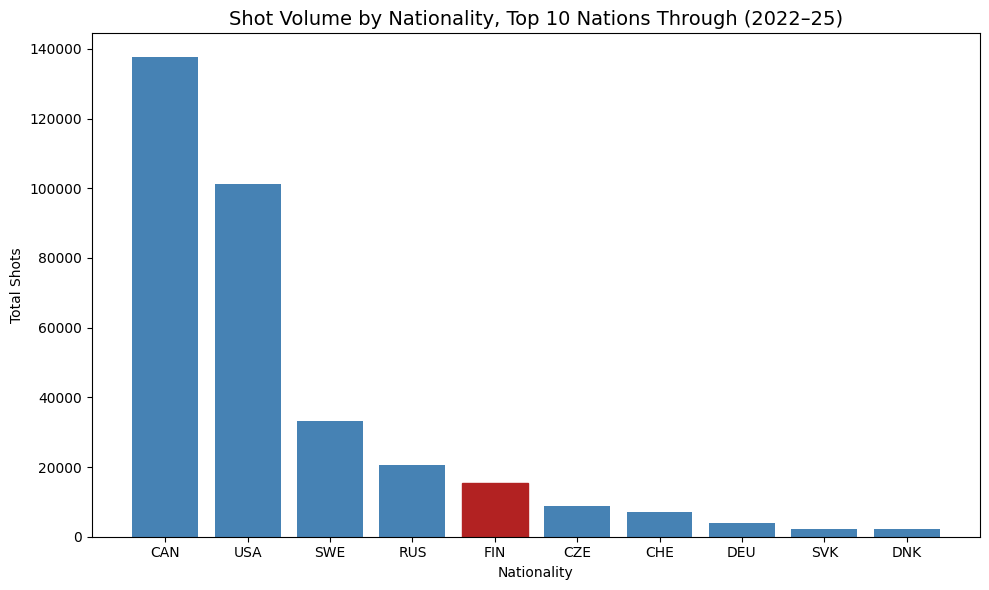

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

top10 = nationality_counts.head(10)
bars = ax.bar(top10.index, top10.values, color='steelblue')

fin_index = list(top10.index).index('FIN')
bars[fin_index].set_color('firebrick')

ax.set_title('Shot Volume by Nationality, Top 10 Nations Through (2022–25)', fontsize=14)
ax.set_xlabel('Nationality')
ax.set_ylabel('Total Shots')

plt.tight_layout()
plt.savefig('../visualizations/01_shot_volume_by_nationality.png', dpi=150)
plt.show()